# Modelo de prediccion usando datos de la bolsa
    En esta practica pondremos a prueba modelos de aprendizaje para realizar prediccion de valores en la bolsa
    y tambien obtendremos sus margenes de error

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import yfinance as yf


# Modelos a trabajar o usar#

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

### Obtenemos las inversiones que tiene Amazon durante el periodo de 01/01/2025 - 01/01/2026

In [17]:
intel_inversion = yf.Ticker('INTC')
data = intel_inversion.history(interval = '1h',start='2025-01-01',end='2026-01-01')
print(data.head())

                                Open       High  ...  Dividends  Stock Splits
Datetime                                         ...                         
2025-01-02 09:30:00-05:00  20.219999  20.430000  ...        0.0           0.0
2025-01-02 10:30:00-05:00  20.135000  20.305401  ...        0.0           0.0
2025-01-02 11:30:00-05:00  20.290001  20.340000  ...        0.0           0.0
2025-01-02 12:30:00-05:00  20.215000  20.230000  ...        0.0           0.0
2025-01-02 13:30:00-05:00  20.129999  20.200001  ...        0.0           0.0

[5 rows x 7 columns]


## Funciones para el Calculo de Error 

Estas funciones serian en base al dato real y el predicho.

In [15]:
def calcular_MSE(y_real, y_pred):
    return np.mean((y_real - y_pred) ** 2)

def calcular_MAE(y_real, y_pred):
    return np.mean(np.abs(y_real - y_pred))

def calcular_RSE(y_real, y_pred):
    numerador   = np.sum((y_real - y_pred) ** 2)
    denominador = np.sum((y_real - np.mean(y_real)) ** 2)
    return numerador / denominador

def calcular_RAE(y_real, y_pred):
    numerador   = np.sum(np.abs(y_real - y_pred))
    denominador = np.sum(np.abs(y_real - np.mean(y_real)))
    return numerador / denominador

def calcular_CC(y_real, y_pred):
    return np.corrcoef(y_real, y_pred)[0, 1]

def calcular_errores(y_real, y_pred):
    return {
        "MSE": calcular_MSE(y_real, y_pred),
        "MAE": calcular_MAE(y_real, y_pred),
        "RSE": calcular_RSE(y_real, y_pred),
        "RAE": calcular_RAE(y_real, y_pred),
        "CC" : calcular_CC(y_real, y_pred)
    }

In [24]:
modelos = {
    "Regresion Lineal"  : LinearRegression()
}

In [10]:
def entrenar_modelos(X_train, y_train, X_test, modelos):
    predicciones = {}
    for nombre, modelo in modelos.items():
        modelo.fit(X_train, y_train)
        predicciones[nombre] = modelo.predict(X_test)
    return predicciones

def imprimir_errores(columna, predicciones, y_test, todos_resultados):
    print(f"\n{'='*50}")
    print(f"  Columna: {columna}")
    print(f"{'='*50}")

    resultados_columna = {}

    for nombre, y_pred in predicciones.items():
        errores = calcular_errores(y_test, y_pred)
        resultados_columna[nombre] = errores

        print(f"\n  Modelo: {nombre}")
        print(f"    MSE: {errores['MSE']:.4f}")
        print(f"    MAE: {errores['MAE']:.4f}")
        print(f"    RSE: {errores['RSE']:.4f}")
        print(f"    RAE: {errores['RAE']:.4f}")
        print(f"    CC:  {errores['CC']:.4f}")

    todos_resultados[columna] = resultados_columna

def imprimir_resumen(todos_resultados):
    for columna, resultados in todos_resultados.items():
        print(f"\n{'='*50}")
        print(f"  Resumen: {columna}")
        print(f"{'='*50}")
        df_resultados = pd.DataFrame(resultados).T
        print(df_resultados.to_string(float_format="{:.4f}".format))

In [38]:
def graficar_por_mes(y_test, y_pred, columna, fechas_test):
    df_plot = pd.DataFrame({
        "fecha"  : fechas_test,
        "y_test" : y_test,
        "y_pred" : y_pred
    })
    df_plot["mes"] = df_plot["fecha"].dt.to_period("M")
    meses = df_plot["mes"].unique()

    for mes in meses:
        df_mes = df_plot[df_plot["mes"] == mes]

        y_real_mes = df_mes["y_test"].values
        y_pred_mes = df_mes["y_pred"].values
        fechas_mes = df_mes["fecha"].values
        error      = np.abs(y_real_mes - y_pred_mes)

        fig, ax = plt.subplots(figsize=(12, 5))  # <- figura individual

        ax.plot(fechas_mes, y_real_mes, color="royalblue", linewidth=2,
                label="Valor Real", zorder=3)

        ax.scatter(fechas_mes, y_pred_mes, color="tomato", s=20,
                   label="Prediccion", zorder=4)

        ax.plot(fechas_mes, y_pred_mes, color="tomato", linewidth=1,
                linestyle="--", alpha=0.7, zorder=2)

        ax.fill_between(fechas_mes,
                         y_pred_mes - error,
                         y_pred_mes + error,
                         alpha=0.2, color="tomato",
                         label="Margen de error")

        ax.set_title(f"{columna} — Regresion Lineal | {mes}",
                     fontsize=13, fontweight="bold")
        ax.set_xlabel("Dia")
        ax.set_ylabel("Valor")
        ax.legend()
        ax.grid(True, linestyle="--", alpha=0.5)

        ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%d"))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha="right")

        plt.tight_layout()
        plt.show()


  Columna: Open

  Modelo: Regresion Lineal
    MSE: 0.0464
    MAE: 0.0636
    RSE: 0.0091
    RAE: 0.0353
    CC:  0.9954


C:\Users\Isaia\AppData\Local\Temp\ipykernel_26788\1610977157.py:7: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_plot["mes"] = df_plot["fecha"].dt.to_period("M")


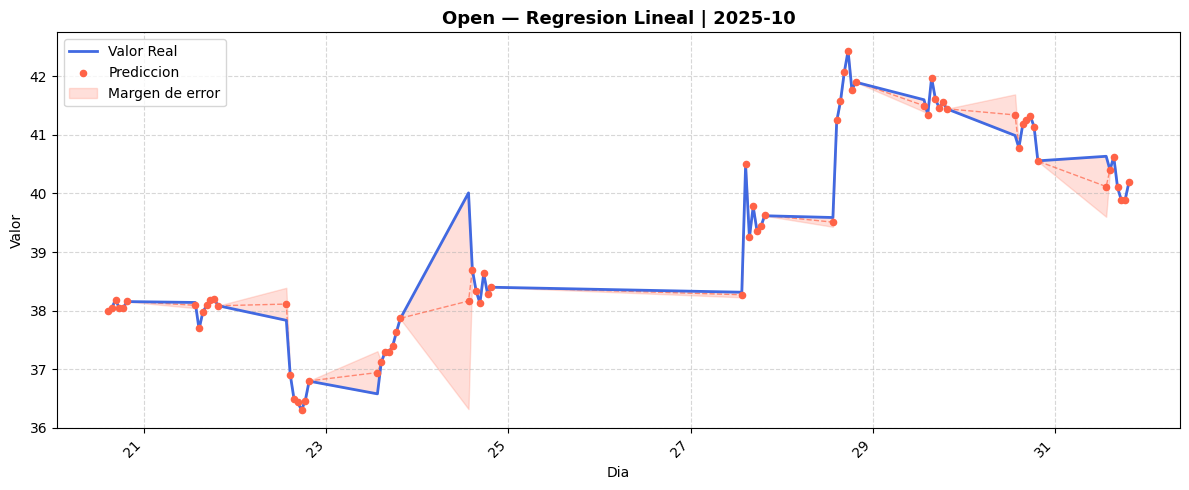

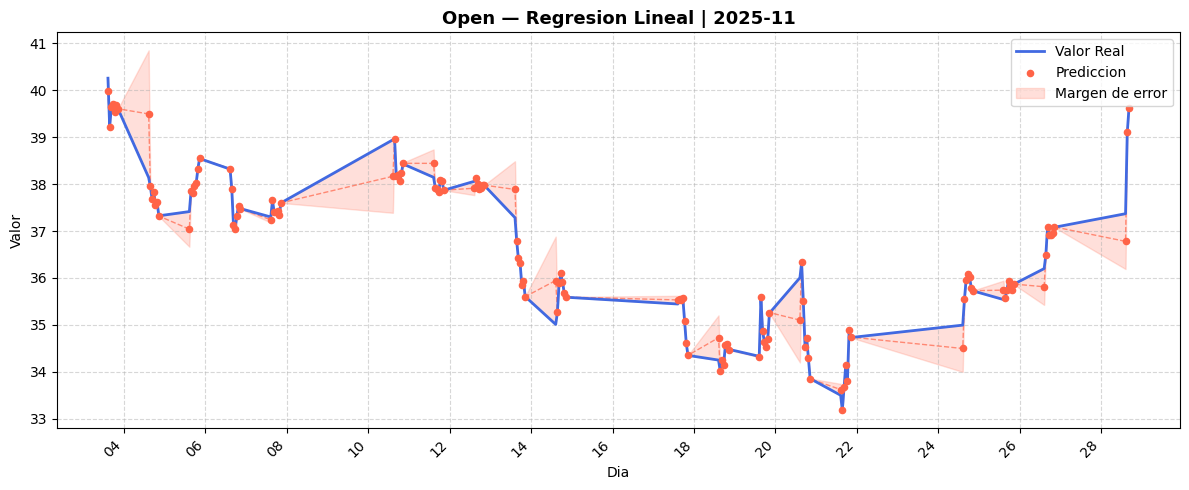

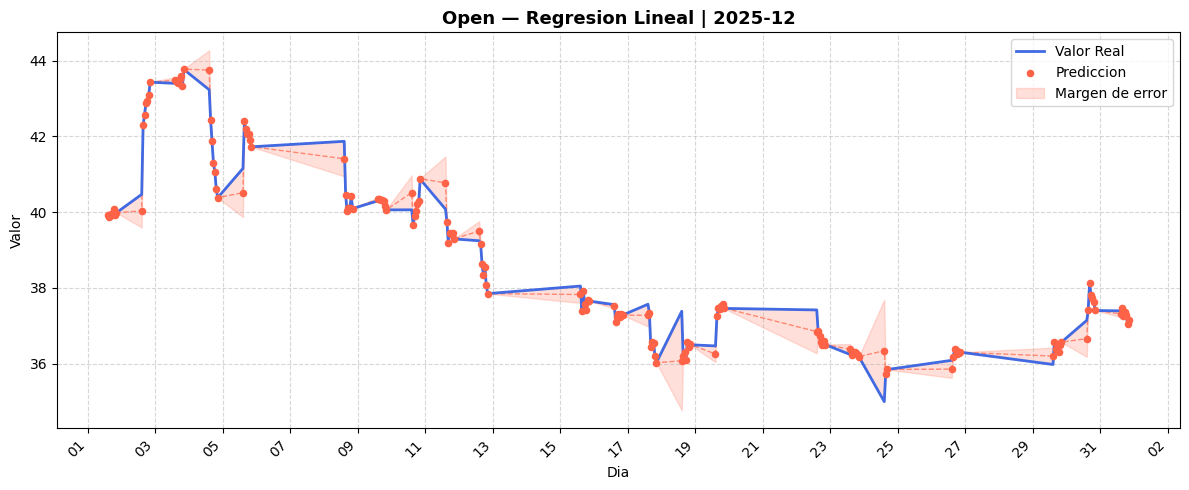


  Columna: High

  Modelo: Regresion Lineal
    MSE: 0.1709
    MAE: 0.2648
    RSE: 0.0328
    RAE: 0.1441
    CC:  0.9840


C:\Users\Isaia\AppData\Local\Temp\ipykernel_26788\1610977157.py:7: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_plot["mes"] = df_plot["fecha"].dt.to_period("M")


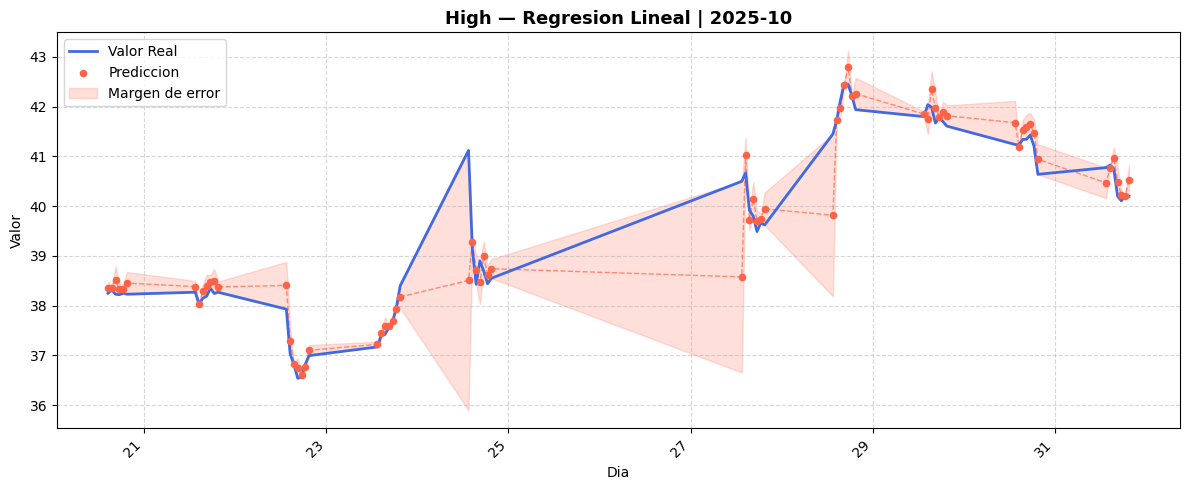

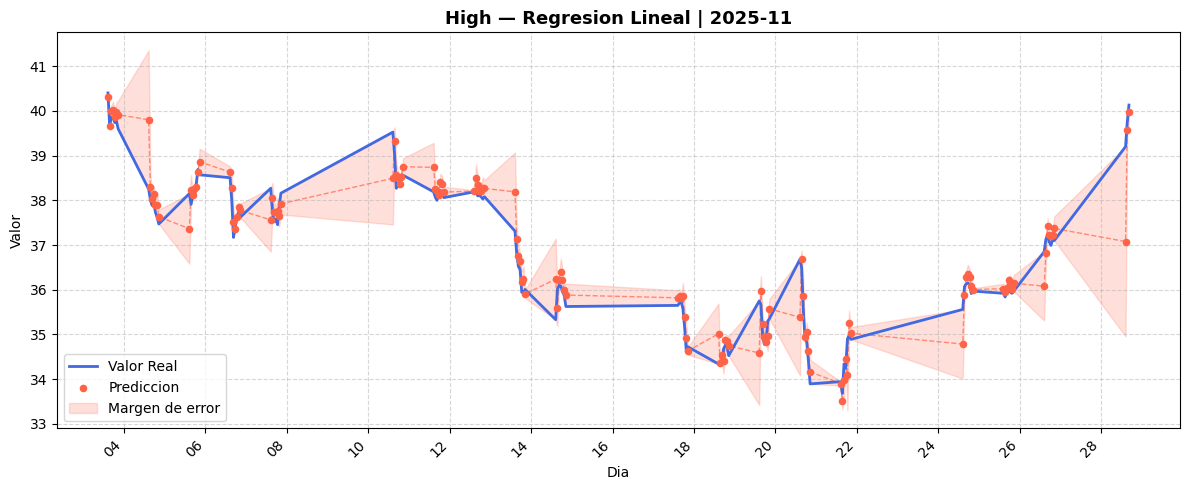

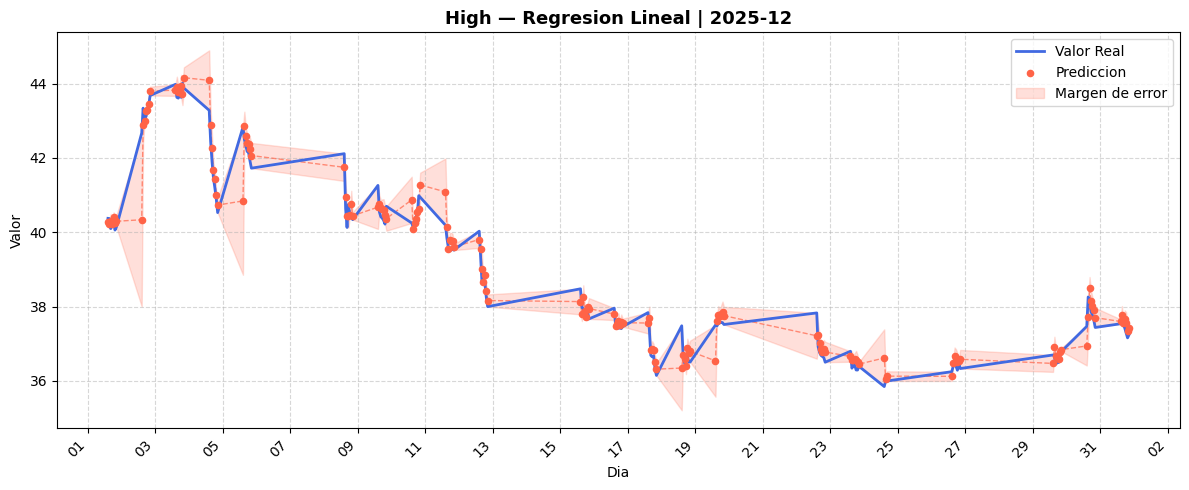


  Columna: Low

  Modelo: Regresion Lineal
    MSE: 0.1095
    MAE: 0.2416
    RSE: 0.0221
    RAE: 0.1365
    CC:  0.9893


C:\Users\Isaia\AppData\Local\Temp\ipykernel_26788\1610977157.py:7: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_plot["mes"] = df_plot["fecha"].dt.to_period("M")


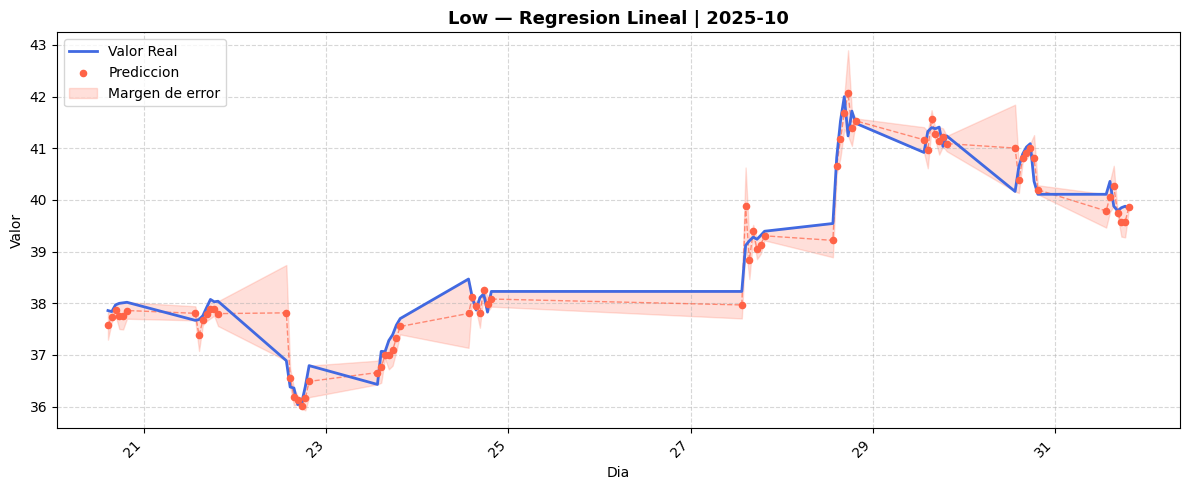

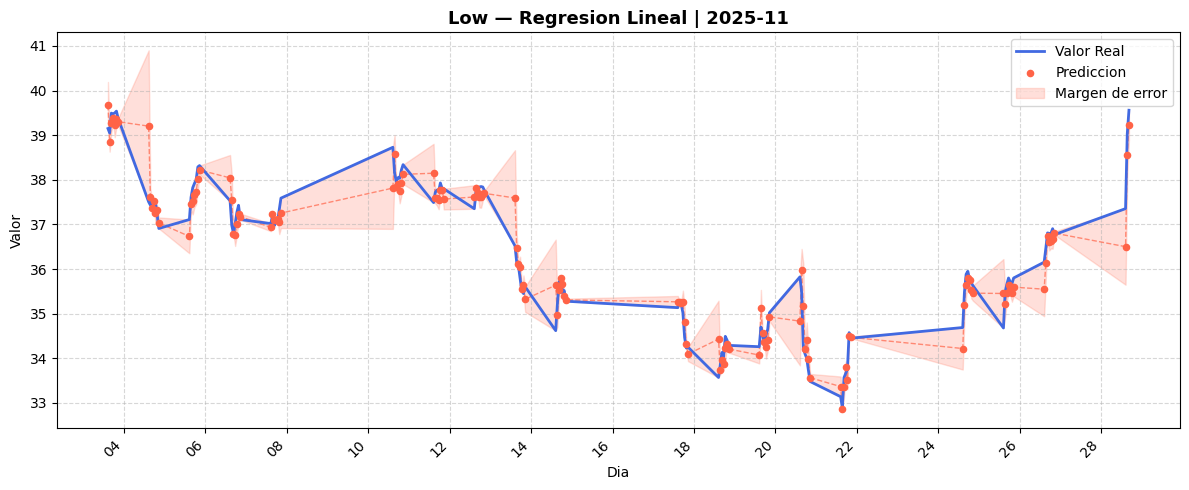

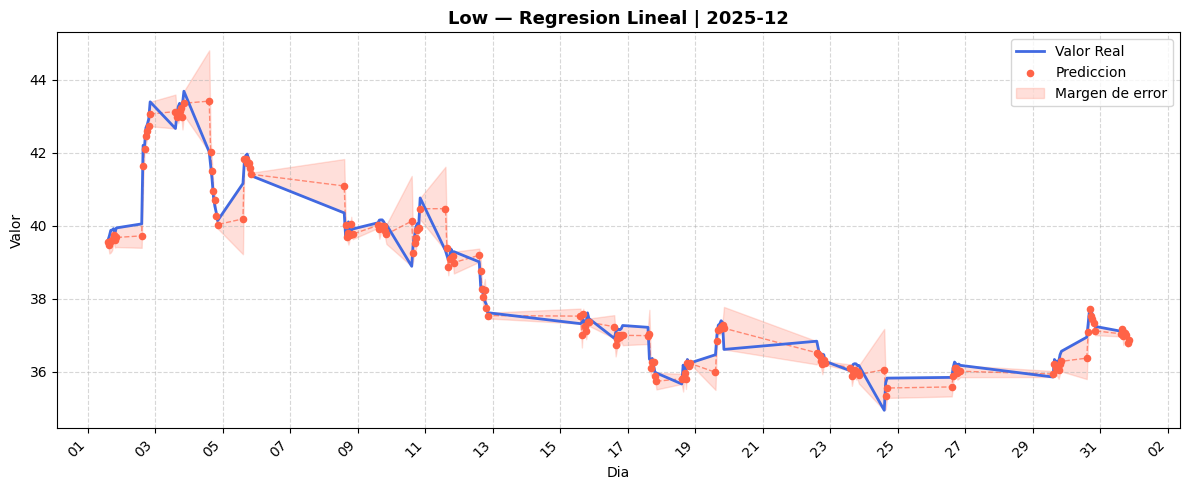


  Columna: Close

  Modelo: Regresion Lineal
    MSE: 0.1960
    MAE: 0.2849
    RSE: 0.0386
    RAE: 0.1581
    CC:  0.9807


C:\Users\Isaia\AppData\Local\Temp\ipykernel_26788\1610977157.py:7: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_plot["mes"] = df_plot["fecha"].dt.to_period("M")


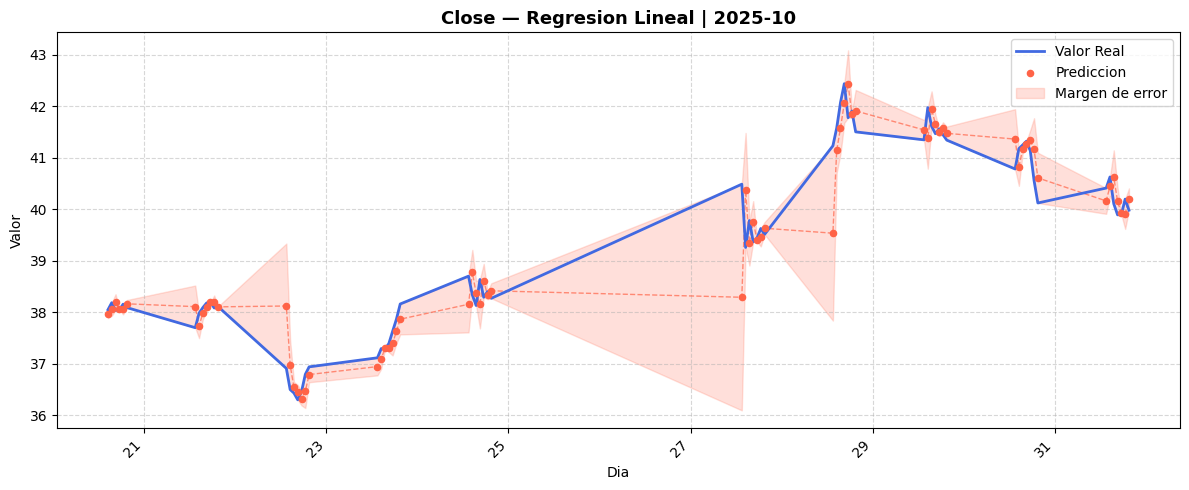

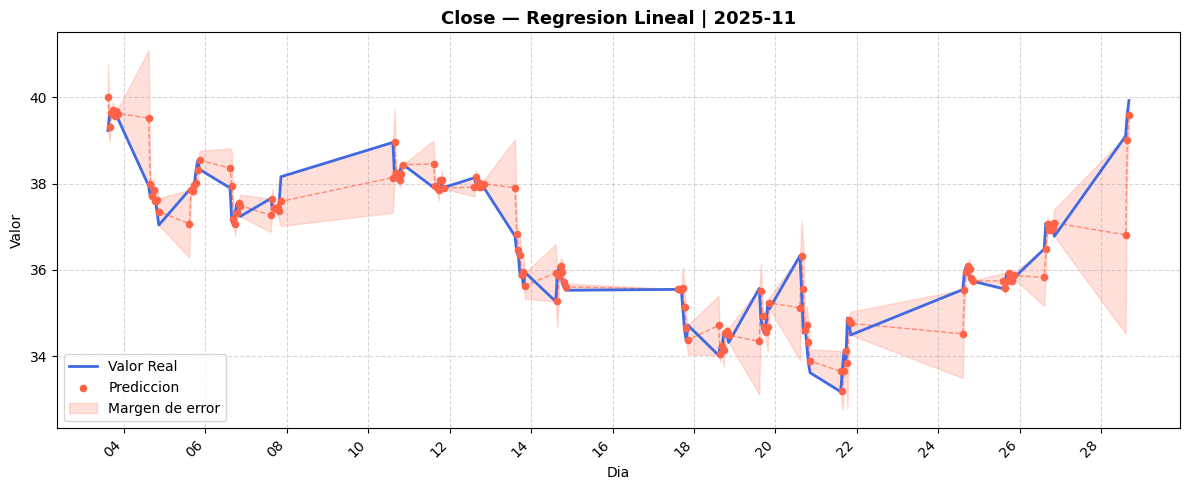

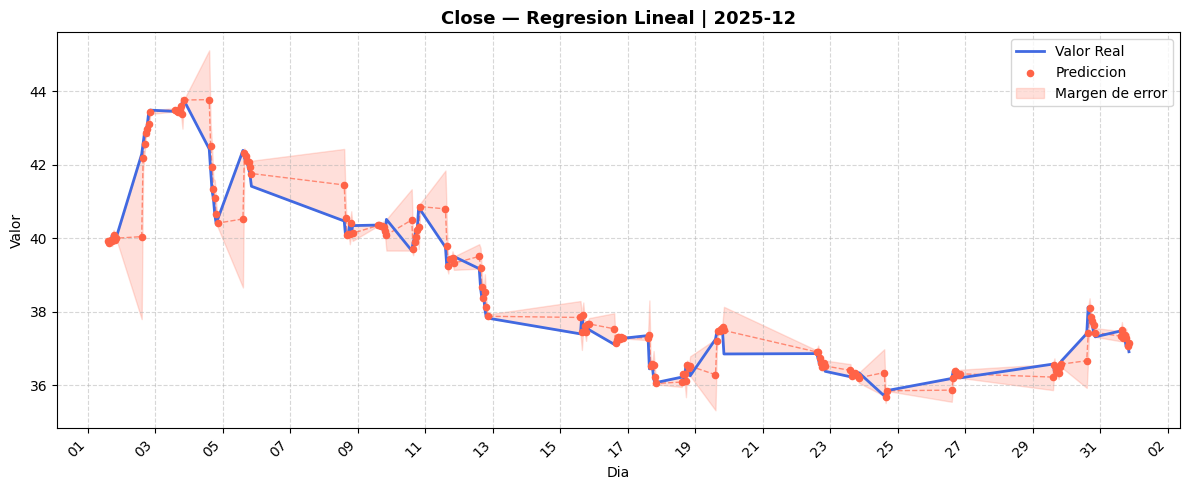


  Resumen: Open
                    MSE    MAE    RSE    RAE     CC
Regresion Lineal 0.0464 0.0636 0.0091 0.0353 0.9954

  Resumen: High
                    MSE    MAE    RSE    RAE     CC
Regresion Lineal 0.1709 0.2648 0.0328 0.1441 0.9840

  Resumen: Low
                    MSE    MAE    RSE    RAE     CC
Regresion Lineal 0.1095 0.2416 0.0221 0.1365 0.9893

  Resumen: Close
                    MSE    MAE    RSE    RAE     CC
Regresion Lineal 0.1960 0.2849 0.0386 0.1581 0.9807


In [ ]:
todos_resultados = {}

columnas = ["Open", "High", "Low", "Close"] 
df_copia = data[["Open", "High", "Low", "Close"]].copy()
df = df_copia.dropna()

for columna in columnas:
    # Usar valores del periodo anterior como predictores
    X = df.shift(1).dropna().values  
    y = df[columna].iloc[1:].values  

    fechas = df.index[1:]

    X_train, X_test_data, y_train, y_test = train_test_split(
        X, y, test_size=0.2, shuffle=False
    )

    fechas_test = fechas[-len(y_test):]

    predicciones = entrenar_modelos(X_train, y_train, X_test_data, modelos)
    imprimir_errores(columna, predicciones, y_test, todos_resultados)
    graficar_por_mes(y_test, predicciones["Regresion Lineal"], columna, fechas_test)

imprimir_resumen(todos_resultados)